# The Perceptron: Foundation of Neural Networks

The perceptron is the basic building block of neural networks, inspired by biological neurons. It's a single-layer neural network that performs binary classification by computing a weighted sum of inputs and applying a threshold.

## Key Components

- **Inputs**: Features or data points
- **Weights**: Learnable parameters that determine the importance of each input
- **Bias**: An offset term that shifts the decision boundary
- **Activation Function**: Typically a step function for binary classification

## Mathematical Representation

For inputs $x_1, x_2, \dots, x_n$, weights $w_1, w_2, \dots, w_n$, and bias $b$:

$$
z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b
$$

$$
\hat{y} = 
\begin{cases} 
1 & \text{if } z \geq 0 \\
0 & \text{if } z < 0 
\end{cases}
$$

## Loss Function

For training, we need a loss function to measure how well the perceptron performs. Common choices include:

- **Mean Squared Error (MSE)** for regression: $L = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$
- **Binary Cross-Entropy** for binary classification: $L = -\frac{1}{n} \sum_{i=1}^n [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$

## Back-Propagation

Back-propagation is the algorithm used to train neural networks by computing gradients of the loss function with respect to the weights and updating them to minimize the loss.

1. **Forward Pass**: Compute predictions
2. **Compute Loss**: Calculate how wrong the predictions are
3. **Backward Pass**: Compute gradients using the chain rule
4. **Update Weights**: Adjust weights in the direction that reduces loss

$$
w \leftarrow w - \eta \frac{\partial L}{\partial w}
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

Where $\eta$ is the learning rate.

This simple perceptron forms the basis for more complex neural networks like multi-layer perceptrons (MLPs).

## What “linear” means

In this context, “linear” means linear in the model parameters (weights and bias), not necessarily a straight line in the original input space. By transforming the input features (for example, using $x$ and $x^2$ or $x$ and $\sin(x)$), a linear model can still fit curved relationships like a quadratic function or a sinusoid while producing a single $y$ for each input $x$.

## The Three Test Cases

To demonstrate that a perceptron can learn different function types with proper feature engineering, we use three datasets:

### 1. Linear Function: $y = 2x_1 + 3x_2 + 1$

- **Input**: 2D random samples $(x_1, x_2)$
- **Target**: Linear combination of inputs plus noise
- **Goal**: Learn the true weights $w_1=2$, $w_2=3$ and bias $b=1$
- **Features**: Raw inputs (no transformation)
- **What it shows**: The basic perceptron learns linear relationships directly

### 2. Quadratic Function: $y = (x-1)^2$

- **Input**: 1D values transformed to 2D: $[x, (x-1)^2]$
- **Target**: Quadratic relationship (shifted)
- **Goal**: Learn weights for the transformed features
- **Features**: $[x, (x-1)^2]$ (feature engineering)
- **What it shows**: A linear model on transformed features can fit curves

### 3. Sine Function: $y = \sin(10x)$

- **Input**: 1D values transformed to 2D: $[x, \sin(10x)]$
- **Target**: Sinusoidal relationship (higher frequency)
- **Goal**: Learn a linear combination of $x$ and $\sin(10x)$
- **Features**: $[x, \sin(10x)]$ (feature engineering)
- **What it shows**: Feature engineering allows approximating complex periodic functions

## Train/Test Split

Each dataset is split 50/50 into **training** and **test** sets:
- **Training set**: Used to learn the weights (gradient descent)
- **Test set**: Unseen data to evaluate generalization

This prevents "cheating" by evaluating on the same data used for training. A good model should perform well on both sets.



In [80]:
pip install torch matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Simple Linear Regression Example: y = 2*x1 + 3*x2 + 1
# We'll create a small dataset and train a perceptron to learn these parameters

# 1. Create synthetic dataset
torch.manual_seed(42)  # For reproducibility
X = torch.randn(200, 2)  # 200 samples, 2 features (increased for train/test split)
true_weights = torch.tensor([2.0, 3.0])
true_bias = 1.0
y = X @ true_weights + true_bias + 0.1 * torch.randn(200)  # Add some noise

# Split into train/test
train_size = 100
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Second dataset: quadratic function with transformed features
X2_full = torch.linspace(-3.0, 3.0, 200).unsqueeze(1)
y2_full = ((X2_full - 1) ** 2).squeeze()
X2_full = torch.cat([X2_full, (X2_full - 1) ** 2], dim=1)  # linear model on [x, (x - 1)^2] features

# Split into train/test
X2_train, X2_test = X2_full[:train_size], X2_full[train_size:]
y2_train, y2_test = y2_full[:train_size], y2_full[train_size:]

# Third dataset: sine function with transformed features
X3_full = torch.linspace(-3.0, 3.0, 200).unsqueeze(1)
y3_full = torch.sin(X3_full*10).squeeze()
X3_full = torch.cat([X3_full, torch.sin(X3_full*10)], dim=1)  # linear model on [x, sin(x*10)] features

# Split into train/test
X3_train, X3_test = X3_full[:train_size], X3_full[train_size:]
y3_train, y3_test = y3_full[:train_size], y3_full[train_size:]


In [82]:
# 2. Define the Perceptron (Single Neuron for Regression)
class Perceptron(nn.Module):
    def __init__(self, input_size):
        super(Perceptron, self).__init__()
        self.linear = nn.Linear(input_size, 1)  # One output for regression

    def forward(self, x):
        return self.linear(x)

# 3. Initialize models, loss, and optimizers
datasets = [
    ("linear", X_train, y_train, X_test, y_test),
    ("quadratic", X2_train, y2_train, X2_test, y2_test),
    ("sin", X3_train, y3_train, X3_test, y3_test),
]

models = [Perceptron(input_size=2) for _ in datasets]

optimizers = [optim.SGD(model.parameters(), lr=0.01) for model in models]
criterion = nn.MSELoss()  # Mean Squared Error for regression

In [83]:
# 4. Training loop
epochs = 500
losses = {name: [] for name, _, _, _, _ in datasets}

print("Training the Perceptrons...")
for epoch in range(epochs):
    for (name, X_train, y_train, _, _), model, optimizer in zip(datasets, models, optimizers):
        predictions = model(X_train).squeeze()
        loss = criterion(predictions, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses[name].append(loss.item())

    if epoch % 10 == 0:  # More frequent logging
        status = ", ".join(f"{name}: {losses[name][-1]:.4f}" for name, _, _, _, _ in datasets)
        print(f"Epoch {epoch}, {status}")

print("\nFinal model parameters:")
for (name, _, _, _, _), model in zip(datasets, models):
    print(f"{name:>10}: weights {model.linear.weight.data.squeeze().tolist()}, bias {model.linear.bias.data.item():.4f}")

# Evaluate on test sets
print("\nTest set performance:")
for (name, _, _, X_test, y_test), model in zip(datasets, models):
    with torch.no_grad():
        test_pred = model(X_test).squeeze()
        test_loss = criterion(test_pred, y_test)
    print(f"{name:>10}: test loss {test_loss.item():.4f}")


Training the Perceptrons...
Epoch 0, linear: 18.5868, quadratic: 120.4845, sin: 1.9468
Epoch 10, linear: 12.1319, quadratic: 0.0035, sin: 0.9956
Epoch 20, linear: 7.9446, quadratic: 0.0034, sin: 0.6945
Epoch 30, linear: 5.2217, quadratic: 0.0033, sin: 0.5452


Epoch 40, linear: 3.4462, quadratic: 0.0033, sin: 0.4427
Epoch 50, linear: 2.2852, quadratic: 0.0033, sin: 0.3629
Epoch 60, linear: 1.5234, quadratic: 0.0032, sin: 0.2985
Epoch 70, linear: 1.0217, quadratic: 0.0032, sin: 0.2459
Epoch 80, linear: 0.6900, quadratic: 0.0031, sin: 0.2029
Epoch 90, linear: 0.4697, quadratic: 0.0031, sin: 0.1677
Epoch 100, linear: 0.3226, quadratic: 0.0031, sin: 0.1388
Epoch 110, linear: 0.2239, quadratic: 0.0031, sin: 0.1151
Epoch 120, linear: 0.1573, quadratic: 0.0030, sin: 0.0956
Epoch 130, linear: 0.1120, quadratic: 0.0030, sin: 0.0796
Epoch 140, linear: 0.0810, quadratic: 0.0030, sin: 0.0664
Epoch 150, linear: 0.0597, quadratic: 0.0029, sin: 0.0556
Epoch 160, linear: 0.0448, quadratic: 0.0029, sin: 0.0467
Epoch 170, linear: 0.0345, quadratic: 0.0029, sin: 0.0393
Epoch 180, linear: 0.0272, quadratic: 0.0029, sin: 0.0331
Epoch 190, linear: 0.0220, quadratic: 0.0028, sin: 0.0281
Epoch 200, linear: 0.0183, quadratic: 0.0028, sin: 0.0239
Epoch 210, linear: 0

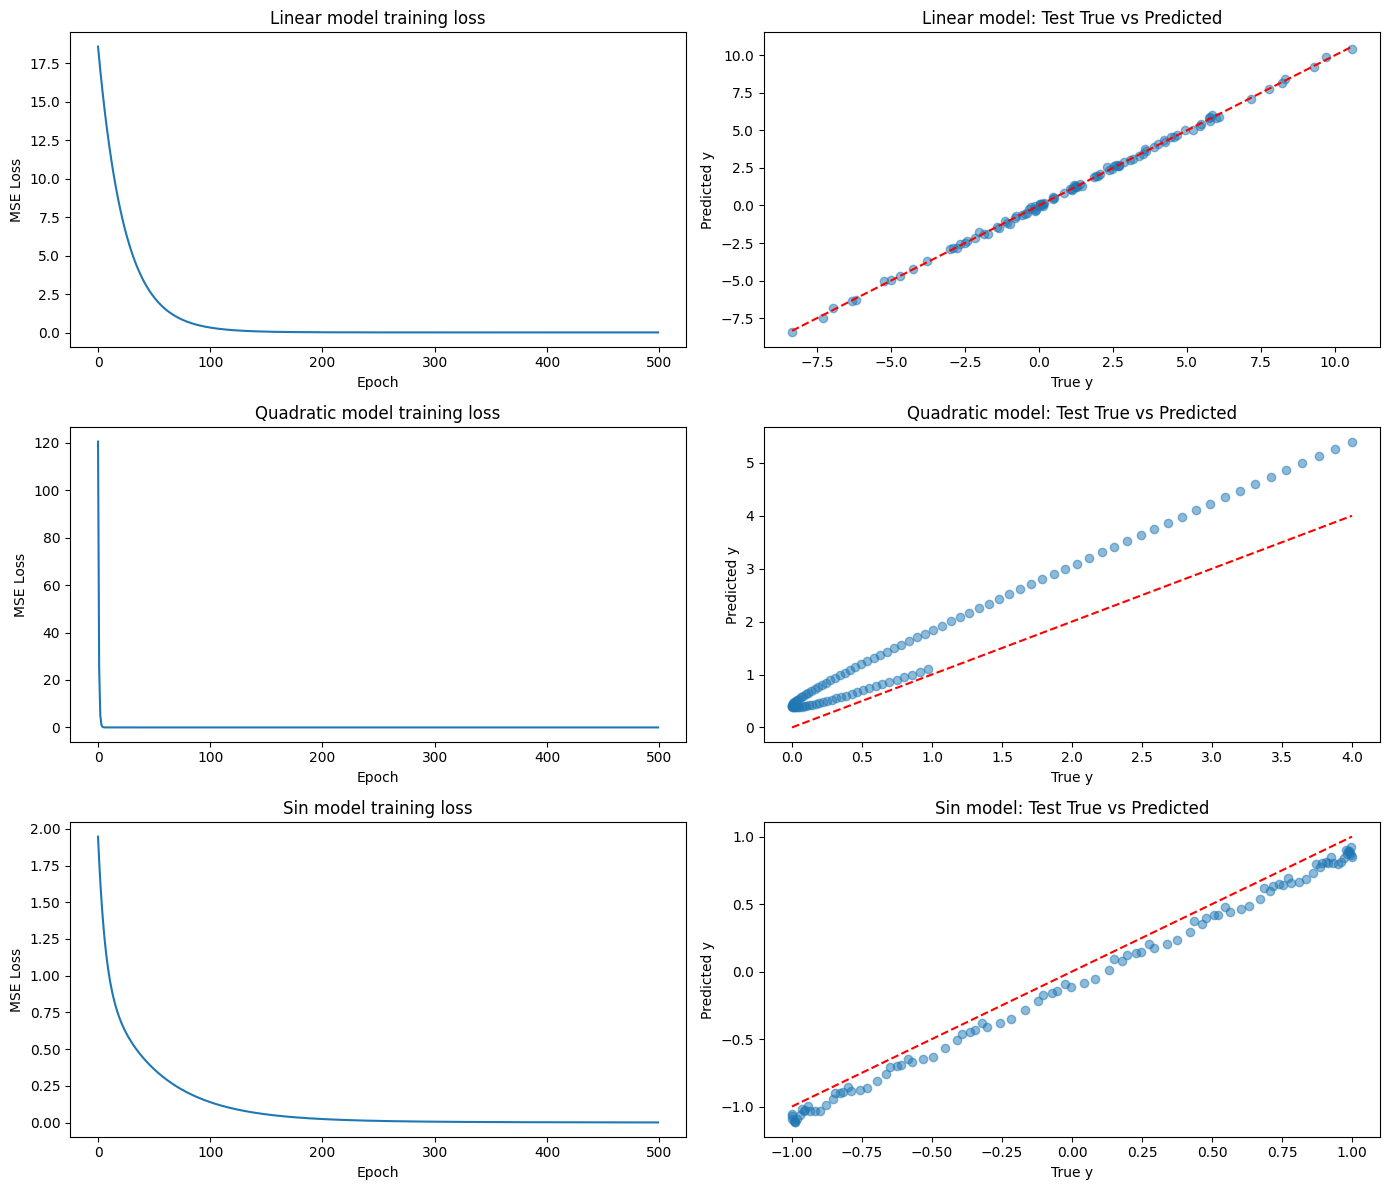

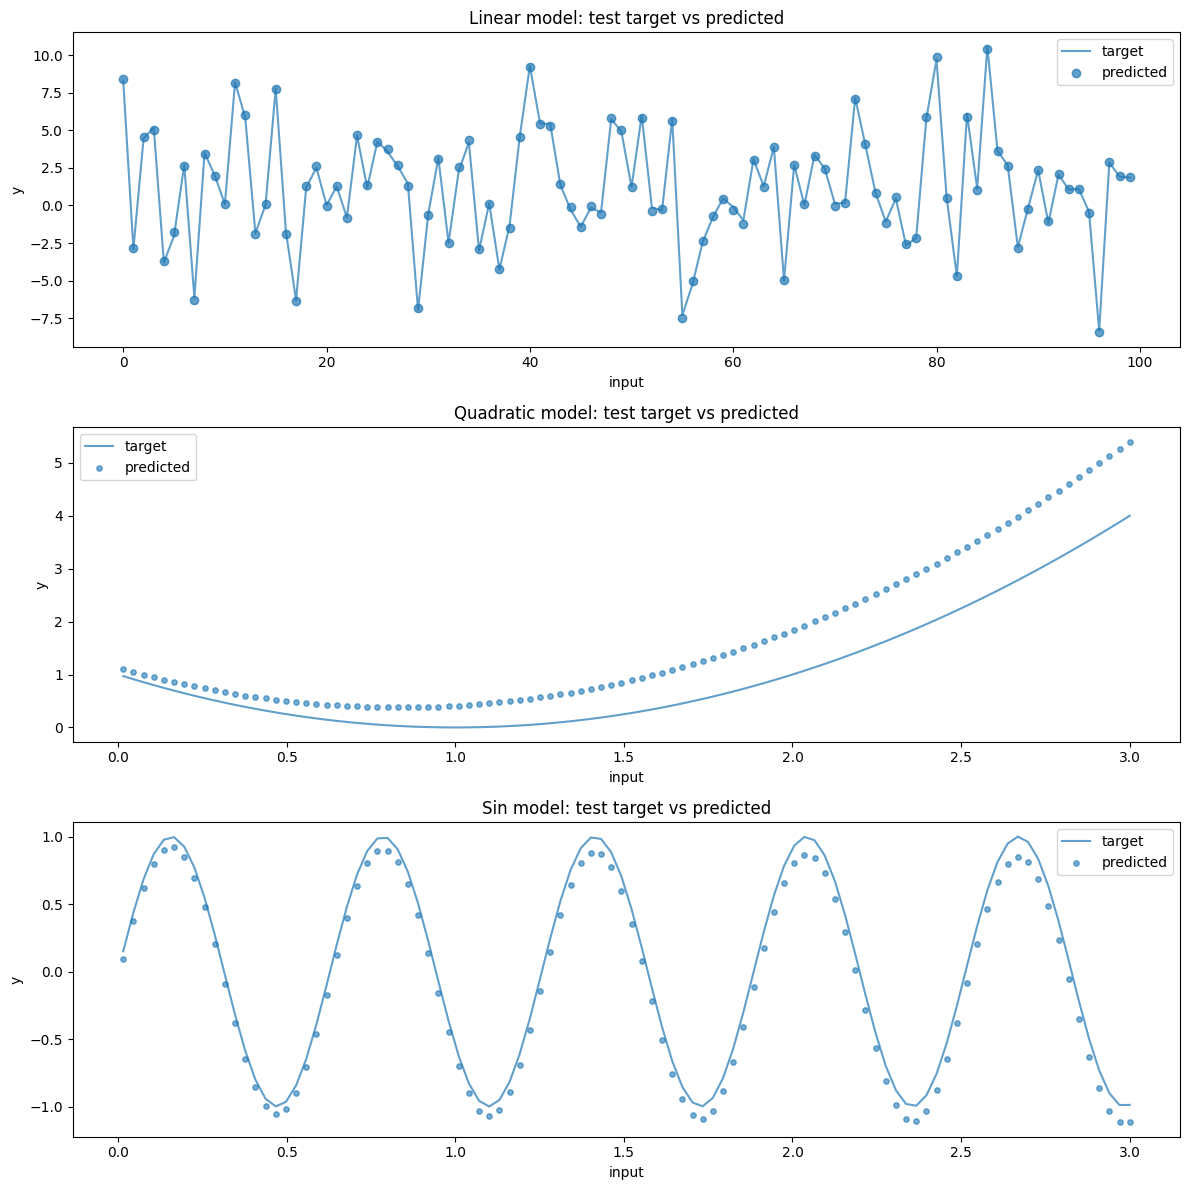

In [84]:
# 5. Visualize the results
plt.figure(figsize=(14, 12))

for idx, (name, X_train, y_train, X_test, y_test) in enumerate(datasets, start=1):
    plt.subplot(3, 2, 2 * idx - 1)
    plt.plot(losses[name])
    plt.title(f"{name.capitalize()} model training loss")
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')

    plt.subplot(3, 2, 2 * idx)
    with torch.no_grad():
        pred = models[idx - 1](X_test).squeeze()
    plt.scatter(y_test.numpy(), pred.numpy(), alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('True y')
    plt.ylabel('Predicted y')
    plt.title(f"{name.capitalize()} model: Test True vs Predicted")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 12))
for idx, (name, _, _, X_test, y_test) in enumerate(datasets, start=1):
    plt.subplot(3, 1, idx)
    with torch.no_grad():
        pred = models[idx - 1](X_test).squeeze().numpy()
    y_np = y_test.numpy()

    if name == 'linear':
        x_axis = torch.arange(len(y_test)).numpy()
        plt.plot(x_axis, y_np, label='target', alpha=0.7)
        plt.scatter(x_axis, pred, label='predicted', alpha=0.7)
    else:
        x_axis = X_test[:, 0].numpy()
        order = x_axis.argsort()
        plt.plot(x_axis[order], y_np[order], label='target', alpha=0.7)
        plt.scatter(x_axis[order], pred[order], label='predicted', alpha=0.6, s=15)

    plt.title(f"{name.capitalize()} model: test target vs predicted")
    plt.xlabel('input')
    plt.ylabel('y')
    plt.legend()

plt.tight_layout()
plt.show()